# Credit Card Fraud Detection
## End-to-End Machine Learning Pipeline

**Author:** Saad Ahsan  
**GitHub:** [github.com/saadahsan0009](https://github.com/saadahsan0009)  
**LinkedIn:** [linkedin.com/in/saad-ahsan-1901sam](https://www.linkedin.com/in/saad-ahsan-1901sam/)

---

## 📌 Project Overview

Credit card fraud causes billions of dollars in losses globally every year. Detecting fraudulent transactions in real time is one of the most important and challenging problems in financial data science.

This project builds an **end-to-end fraud detection pipeline** using real anonymised transaction data, tackling one of the most common real-world challenges in machine learning — **severely imbalanced datasets** — where fraudulent transactions represent only 0.17% of all transactions.

### 🎯 Objectives
- Handle severely imbalanced data using **SMOTE** (Synthetic Minority Oversampling Technique)
- Compare three classification models: **Logistic Regression**, **Random Forest**, and **XGBoost**
- Evaluate models using metrics appropriate for imbalanced classification: **ROC-AUC**, **Precision-Recall**, **F1-Score**
- Apply **SHAP** (SHapley Additive exPlanations) to explain model predictions
- Build a reusable, production-style pipeline

### 📊 Dataset
- **Source:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- **Size:** 284,807 transactions over two days in September 2013
- **Fraud rate:** 492 frauds out of 284,807 transactions (0.172%)
- **Features:** 30 features — Time, Amount, and V1–V28 (PCA-transformed for privacy)
- **Target:** Class (0 = legitimate, 1 = fraud)

---

## 📋 Table of Contents
1. [Environment Setup & Imports](#1)
2. [Load & Explore the Data](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing](#4)
5. [Handling Class Imbalance with SMOTE](#5)
6. [Model Training & Evaluation](#6)
7. [Model Comparison](#7)
8. [SHAP Explainability](#8)
9. [Conclusions](#9)

---
## 1. Environment Setup & Imports <a id='1'></a>

In [1]:
# Install required libraries if not already installed
# Uncomment and run if needed:
!pip install imbalanced-learn shap xgboost

# ── Core data manipulation ──
import numpy as np
import pandas as pd

# ── Visualisation ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Machine learning — preprocessing ──
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# ── Machine learning — models ──
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Handling imbalanced data ──
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Model evaluation ──
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score
)

# ── SHAP explainability ──
import shap

# ── Utility ──
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot styling ──
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


---
## 2. Load & Explore the Data <a id='2'></a>

We start by loading the dataset and understanding its basic structure — shape, data types, missing values, and class distribution.

In [2]:
# Load the dataset
# Make sure creditcard.csv is in the same directory as this notebook
df = pd.read_csv('creditcard.csv')

print('Dataset shape:', df.shape)
print(f'\nRows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print('\nFirst 5 rows:')
df.head()

Dataset shape: (284807, 31)

Rows: 284,807
Columns: 31

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Check data types and missing values
print('Data types:')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print('\nBasic statistics:')
df.describe()

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values: 0

Basic statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
# Examine class distribution — this is the core challenge of fraud detection
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(f'  Legitimate transactions (0): {class_counts[0]:,} ({class_pct[0]:.3f}%)')
print(f'  Fraudulent transactions (1): {class_counts[1]:,} ({class_pct[1]:.3f}%)')
print(f'\nImbalance ratio: {class_counts[0]/class_counts[1]:.0f}:1')
print('\n⚠️  This is a severely imbalanced dataset.')
print('   A naive model predicting ALL transactions as legitimate')
print(f'   would achieve {class_pct[0]:.2f}% accuracy — but would miss every fraud!')
print('   This is why we cannot rely on accuracy alone as our metric.')

Class Distribution:
  Legitimate transactions (0): 284,315 (99.827%)
  Fraudulent transactions (1): 492 (0.173%)

Imbalance ratio: 578:1

⚠️  This is a severely imbalanced dataset.
   A naive model predicting ALL transactions as legitimate
   would achieve 99.83% accuracy — but would miss every fraud!
   This is why we cannot rely on accuracy alone as our metric.


---
## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

Before building models, we explore the data visually to understand:
- How transaction amounts differ between fraud and legitimate transactions
- Whether transaction timing shows any fraud patterns
- Which features show the clearest separation between classes

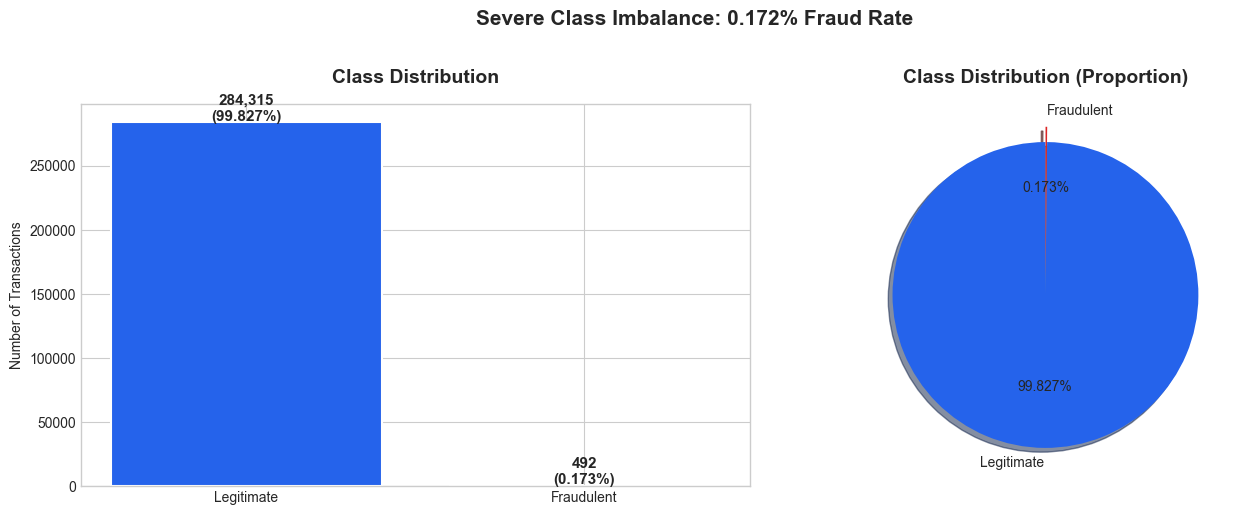

In [5]:
# ── Plot 1: Class imbalance visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2563EB', '#DC2626']
axes[0].bar(['Legitimate', 'Fraudulent'], class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({class_pct.values[i]:.3f}%)', 
                ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraudulent'],
            colors=colors, autopct='%1.3f%%', startangle=90,
            explode=(0, 0.1), shadow=True)
axes[1].set_title('Class Distribution (Proportion)', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Severe Class Imbalance: 0.172% Fraud Rate', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Legitimate — Mean: £88.29, Median: £22.00, Max: £25691.16
Fraudulent — Mean: £122.21, Median: £9.25, Max: £2125.87


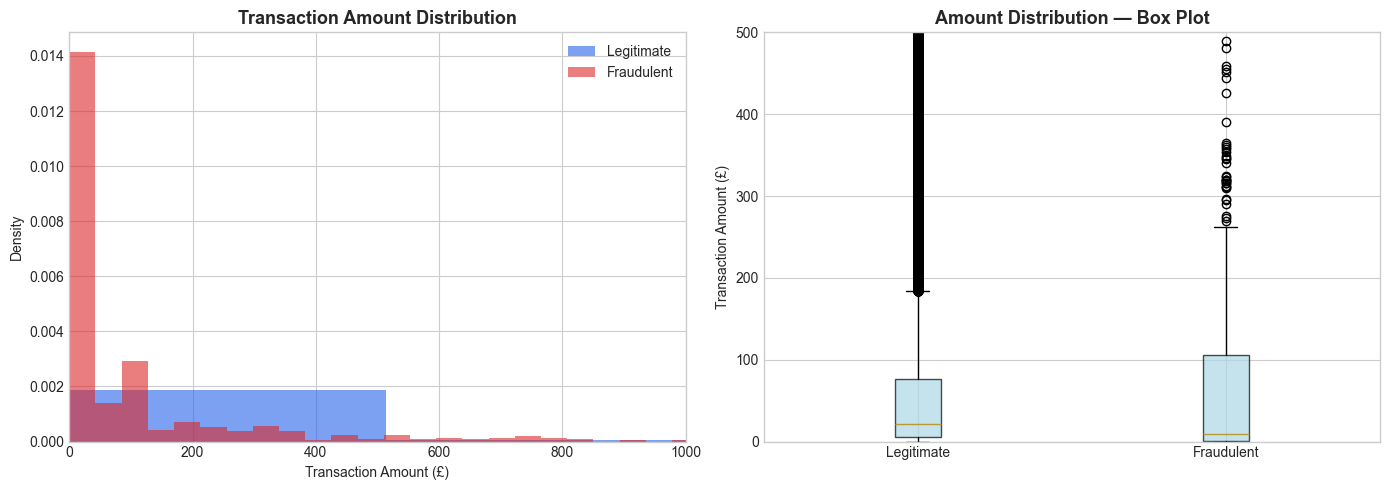

In [6]:
# Create figures directory to save plots
import os
os.makedirs('figures', exist_ok=True)

# ── Plot 2: Transaction amount distribution by class ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate legitimate and fraudulent
legitimate = df[df['Class'] == 0]['Amount']
fraudulent = df[df['Class'] == 1]['Amount']

# Distribution plot
axes[0].hist(legitimate, bins=50, alpha=0.6, color='#2563EB', label='Legitimate', density=True)
axes[0].hist(fraudulent, bins=50, alpha=0.6, color='#DC2626', label='Fraudulent', density=True)
axes[0].set_xlabel('Transaction Amount (£)')
axes[0].set_ylabel('Density')
axes[0].set_title('Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 1000)  # Focus on the main range

# Box plot
df_plot = df[['Amount', 'Class']].copy()
df_plot['Class'] = df_plot['Class'].map({0: 'Legitimate', 1: 'Fraudulent'})
axes[1].boxplot([legitimate, fraudulent], labels=['Legitimate', 'Fraudulent'],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_ylabel('Transaction Amount (£)')
axes[1].set_title('Amount Distribution — Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 500)

print(f'Legitimate — Mean: £{legitimate.mean():.2f}, Median: £{legitimate.median():.2f}, Max: £{legitimate.max():.2f}')
print(f'Fraudulent — Mean: £{fraudulent.mean():.2f}, Median: £{fraudulent.median():.2f}, Max: £{fraudulent.max():.2f}')

plt.tight_layout()
plt.savefig('figures/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

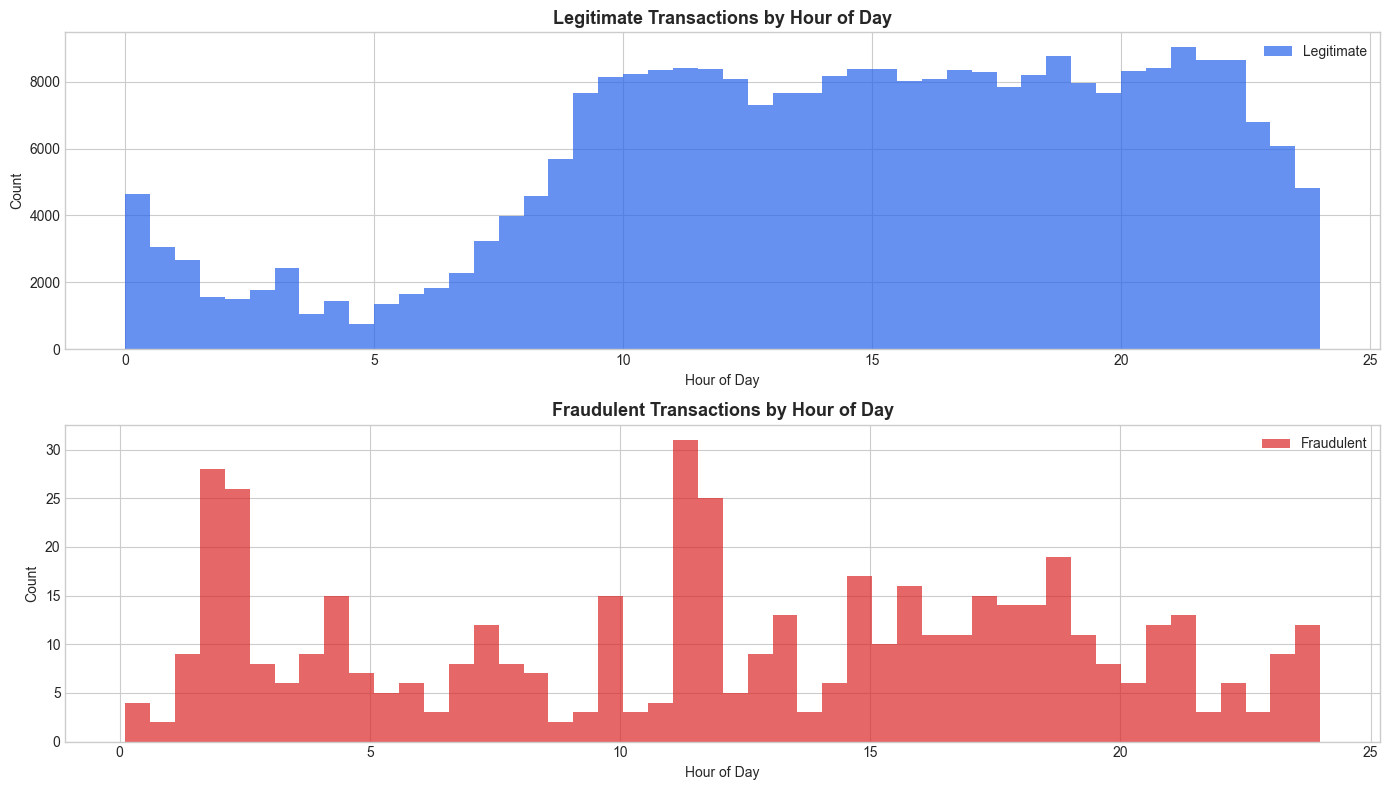

💡 Insight: Legitimate transactions drop significantly at night (2-6am).
   Fraudulent transactions are more evenly distributed across hours,
   with a notable spike during low-activity periods.


In [7]:
# ── Plot 3: Transaction time patterns ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Convert time to hours for readability
df['Hour'] = (df['Time'] / 3600) % 24

# Legitimate transactions over time
axes[0].hist(df[df['Class']==0]['Hour'], bins=48, color='#2563EB', alpha=0.7, label='Legitimate')
axes[0].set_title('Legitimate Transactions by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')
axes[0].legend()

# Fraudulent transactions over time
axes[1].hist(df[df['Class']==1]['Hour'], bins=48, color='#DC2626', alpha=0.7, label='Fraudulent')
axes[1].set_title('Fraudulent Transactions by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Insight: Legitimate transactions drop significantly at night (2-6am).')
print('   Fraudulent transactions are more evenly distributed across hours,')
print('   with a notable spike during low-activity periods.')

Top 6 features with largest mean difference between classes: ['V3', 'V14', 'V17', 'V12', 'V10', 'V7']


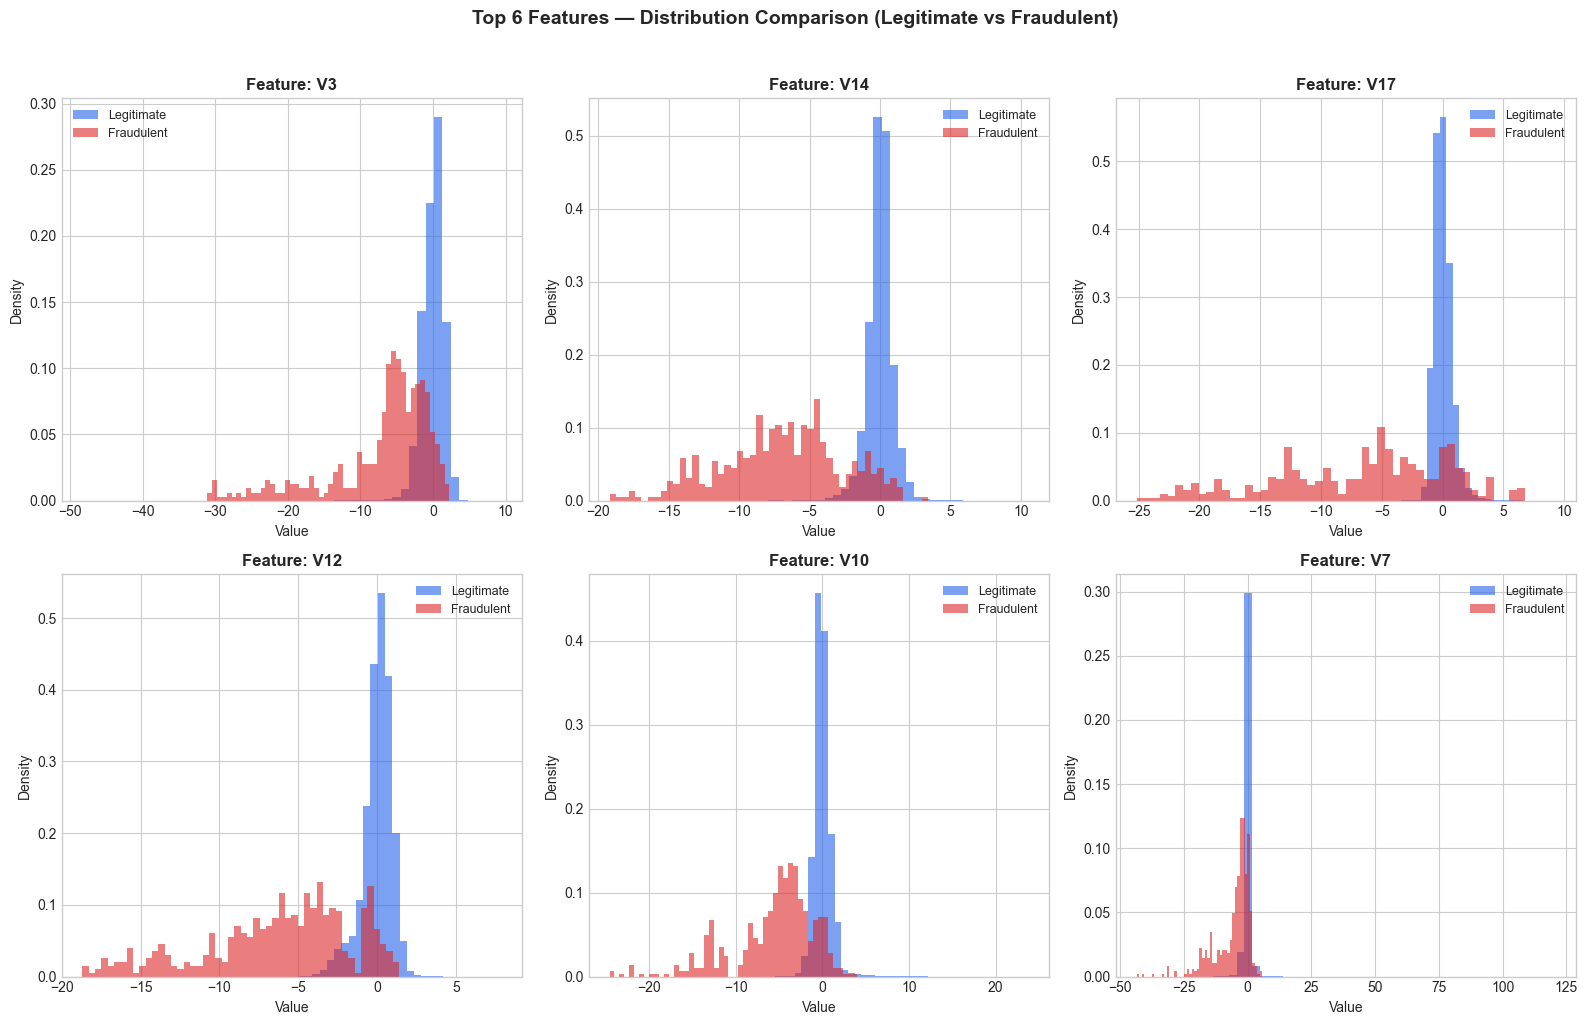

In [8]:
# ── Plot 4: Feature distributions — top features most different between classes ──
# We'll look at V features that show the clearest separation

# Calculate the mean difference between classes for each V feature
v_features = [f'V{i}' for i in range(1, 29)]
mean_diff = abs(df[df['Class']==0][v_features].mean() - df[df['Class']==1][v_features].mean())
top_features = mean_diff.nlargest(6).index.tolist()

print(f'Top 6 features with largest mean difference between classes: {top_features}')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].hist(df[df['Class']==0][feature], bins=50, alpha=0.6, 
                color='#2563EB', label='Legitimate', density=True)
    axes[i].hist(df[df['Class']==1][feature], bins=50, alpha=0.6, 
                color='#DC2626', label='Fraudulent', density=True)
    axes[i].set_title(f'Feature: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Top 6 Features — Distribution Comparison (Legitimate vs Fraudulent)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Data Preprocessing <a id='4'></a>

Before training models, we need to:
1. **Scale** the `Amount` and `Time` features — the V1–V28 features are already PCA-transformed and scaled, but Amount and Time are in their original units
2. **Split** the data into training and test sets using **stratified splitting** to preserve the class ratio in both sets

In [9]:
# ── Feature scaling ──
# Amount and Time need to be scaled to match the range of V1-V28 features
# We use StandardScaler: (x - mean) / std → mean=0, std=1

scaler = StandardScaler()

# Scale Amount and Time, store as new columns
df['scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original Amount, Time, and Hour columns
df_processed = df.drop(['Amount', 'Time', 'Hour'], axis=1)

print('✅ Scaling complete')
print(f'Processed dataset shape: {df_processed.shape}')
print('\nNew features added: scaled_Amount, scaled_Time')
print('Original Amount and Time columns removed')

✅ Scaling complete
Processed dataset shape: (284807, 31)

New features added: scaled_Amount, scaled_Time
Original Amount and Time columns removed


In [10]:
# ── Train / Test split ──
# Stratified split ensures both sets maintain the same 0.172% fraud ratio
# This is important — a random split might put very few fraud cases in the test set

X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 80% train, 20% test
    random_state=RANDOM_STATE,
    stratify=y               # preserve class ratio in both sets
)

print('✅ Train/test split complete')
print(f'\nTraining set:  {X_train.shape[0]:,} samples')
print(f'  Legitimate:  {(y_train==0).sum():,} ({(y_train==0).mean()*100:.3f}%)')
print(f'  Fraudulent:  {(y_train==1).sum():,} ({(y_train==1).mean()*100:.3f}%)')
print(f'\nTest set:      {X_test.shape[0]:,} samples')
print(f'  Legitimate:  {(y_test==0).sum():,} ({(y_test==0).mean()*100:.3f}%)')
print(f'  Fraudulent:  {(y_test==1).sum():,} ({(y_test==1).mean()*100:.3f}%)')

✅ Train/test split complete

Training set:  227,845 samples
  Legitimate:  227,451 (99.827%)
  Fraudulent:  394 (0.173%)

Test set:      56,962 samples
  Legitimate:  56,864 (99.828%)
  Fraudulent:  98 (0.172%)


---
## 5. Handling Class Imbalance with SMOTE <a id='5'></a>

### Why class imbalance is a problem
With only 0.172% fraud, a model that predicts everything as legitimate achieves 99.83% accuracy but catches **zero fraud**. This is useless in practice.

### What is SMOTE?
**SMOTE (Synthetic Minority Oversampling Technique)** creates **synthetic** fraud samples by:
1. Taking a fraud sample
2. Finding its nearest neighbours in feature space
3. Creating new samples along the line between them

This gives the model more fraud examples to learn from without simply duplicating existing ones.

⚠️ **Important:** SMOTE is applied **only on training data** — never on test data. The test set must reflect real-world conditions.

In [11]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('✅ SMOTE applied to training data only')
print(f'\nBefore SMOTE:')
print(f'  Training set size:  {len(X_train):,}')
print(f'  Legitimate:         {(y_train==0).sum():,}')
print(f'  Fraudulent:         {(y_train==1).sum():,}')
print(f'\nAfter SMOTE:')
print(f'  Training set size:  {len(X_train_smote):,}')
print(f'  Legitimate:         {(y_train_smote==0).sum():,}')
print(f'  Fraudulent:         {(y_train_smote==1).sum():,}')
print(f'\n  Synthetic fraud samples created: {(y_train_smote==1).sum() - (y_train==1).sum():,}')
print(f'  New class ratio: 50/50 balanced')

✅ SMOTE applied to training data only

Before SMOTE:
  Training set size:  227,845
  Legitimate:         227,451
  Fraudulent:         394

After SMOTE:
  Training set size:  454,902
  Legitimate:         227,451
  Fraudulent:         227,451

  Synthetic fraud samples created: 227,057
  New class ratio: 50/50 balanced


---
## 6. Model Training & Evaluation <a id='6'></a>

### Evaluation metrics for imbalanced data
For fraud detection, we care about:
- **Recall (Sensitivity):** Of all actual frauds, how many did we catch? Missing fraud is costly.
- **Precision:** Of all predicted frauds, how many were real? Too many false alarms frustrates customers.
- **F1-Score:** Harmonic mean of precision and recall — balances both
- **ROC-AUC:** Overall discriminative ability across all thresholds
- **PR-AUC (Average Precision):** More informative than ROC-AUC for heavily imbalanced data

We train 3 models in order of complexity:
1. **Logistic Regression** — simple, fast, interpretable baseline
2. **Random Forest** — ensemble of decision trees, handles non-linearity
3. **XGBoost** — gradient boosting, typically best performance on tabular data

In [12]:
# ── Helper function for model evaluation ──
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates a trained classifier and prints a comprehensive report.
    
    Parameters:
        model: trained sklearn-compatible classifier
        X_test: test features
        y_test: true labels
        model_name: string name for display
    
    Returns:
        dict of evaluation metrics
    """
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of fraud
    
    # Metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    
    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    print(f'  ROC-AUC Score:        {roc_auc:.4f}')
    print(f'  Average Precision:    {avg_precision:.4f}')
    print(f'  F1 Score (fraud):     {f1:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, 
                                target_names=['Legitimate', 'Fraudulent']))
    
    return {
        'name': model_name,
        'roc_auc': roc_auc,
        'avg_precision': avg_precision,
        'f1': f1,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

print('✅ Evaluation function defined')

✅ Evaluation function defined


In [13]:
# ── Model 1: Logistic Regression (Baseline) ──
# Simple, fast, interpretable — establishes a performance floor
# max_iter=1000 ensures convergence on this dataset size

print('Training Logistic Regression...')
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'  # additional handling for imbalance
)
lr_model.fit(X_train_smote, y_train_smote)
lr_results = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression (Baseline)')

Training Logistic Regression...

  Logistic Regression (Baseline)
  ROC-AUC Score:        0.9699
  Average Precision:    0.7250
  F1 Score (fraud):     0.1092

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
  Fraudulent       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [14]:
# ── Model 2: Random Forest ──
# Ensemble of decision trees — handles non-linear relationships
# n_estimators=100: number of trees in the forest
# n_jobs=-1: use all CPU cores for faster training

print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,             # limit tree depth to prevent overfitting
    min_samples_split=10,     # minimum samples required to split a node
    random_state=RANDOM_STATE,
    n_jobs=-1,                # use all available CPU cores
    class_weight='balanced'
)
rf_model.fit(X_train_smote, y_train_smote)
rf_results = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

Training Random Forest...

  Random Forest
  ROC-AUC Score:        0.9793
  Average Precision:    0.7979
  F1 Score (fraud):     0.5646

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.42      0.85      0.56        98

    accuracy                           1.00     56962
   macro avg       0.71      0.92      0.78     56962
weighted avg       1.00      1.00      1.00     56962



In [15]:
# ── Model 3: XGBoost ──
# Gradient boosting — builds trees sequentially, each correcting the previous
# Typically achieves best performance on structured/tabular data
# scale_pos_weight: additional imbalance handling (ratio of negative to positive)

# Note: we train on SMOTE data so scale_pos_weight = 1 (already balanced)
print('Training XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,            # use 80% of data per tree (reduces overfitting)
    colsample_bytree=0.8,     # use 80% of features per tree
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_results = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

Training XGBoost...

  XGBoost
  ROC-AUC Score:        0.9790
  Average Precision:    0.8619
  F1 Score (fraud):     0.7173

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.61      0.87      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962



---
## 7. Model Comparison <a id='7'></a>

Now we visualise and compare all three models side by side using:
- **ROC Curves** — trade-off between True Positive Rate and False Positive Rate
- **Precision-Recall Curves** — more informative for imbalanced datasets
- **Confusion Matrices** — shows exactly what each model gets right and wrong
- **Metrics Summary Table** — clean comparison of all key numbers

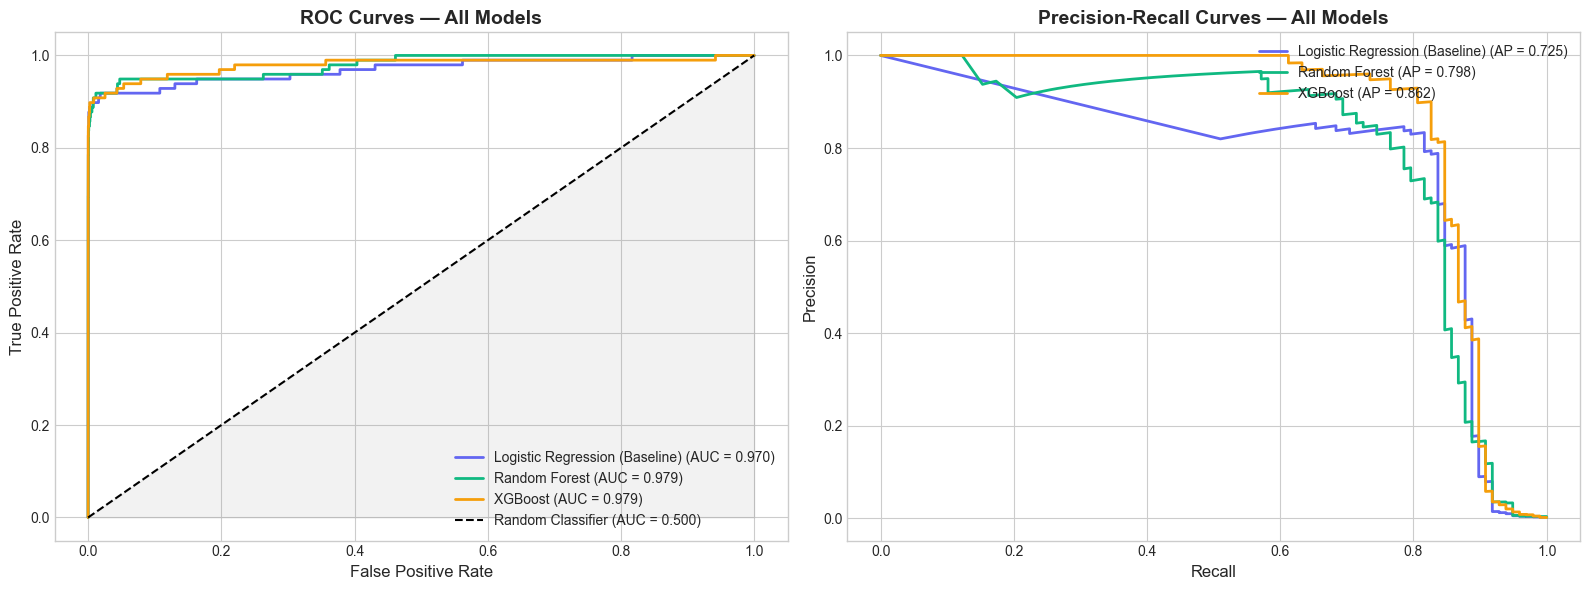

In [16]:
# ── ROC Curves ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_results = [lr_results, rf_results, xgb_results]
colors = ['#6366F1', '#10B981', '#F59E0B']

# ROC Curve
for result, color in zip(models_results, colors):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                label=f"{result['name']} (AUC = {result['roc_auc']:.3f})")

axes[0].plot([0,1], [0,1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].fill_between([0,1], [0,1], alpha=0.1, color='grey')

# Precision-Recall Curve
for result, color in zip(models_results, colors):
    precision, recall, _ = precision_recall_curve(y_test, result['y_prob'])
    axes[1].plot(recall, precision, color=color, lw=2,
                label=f"{result['name']} (AP = {result['avg_precision']:.3f})")

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('figures/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

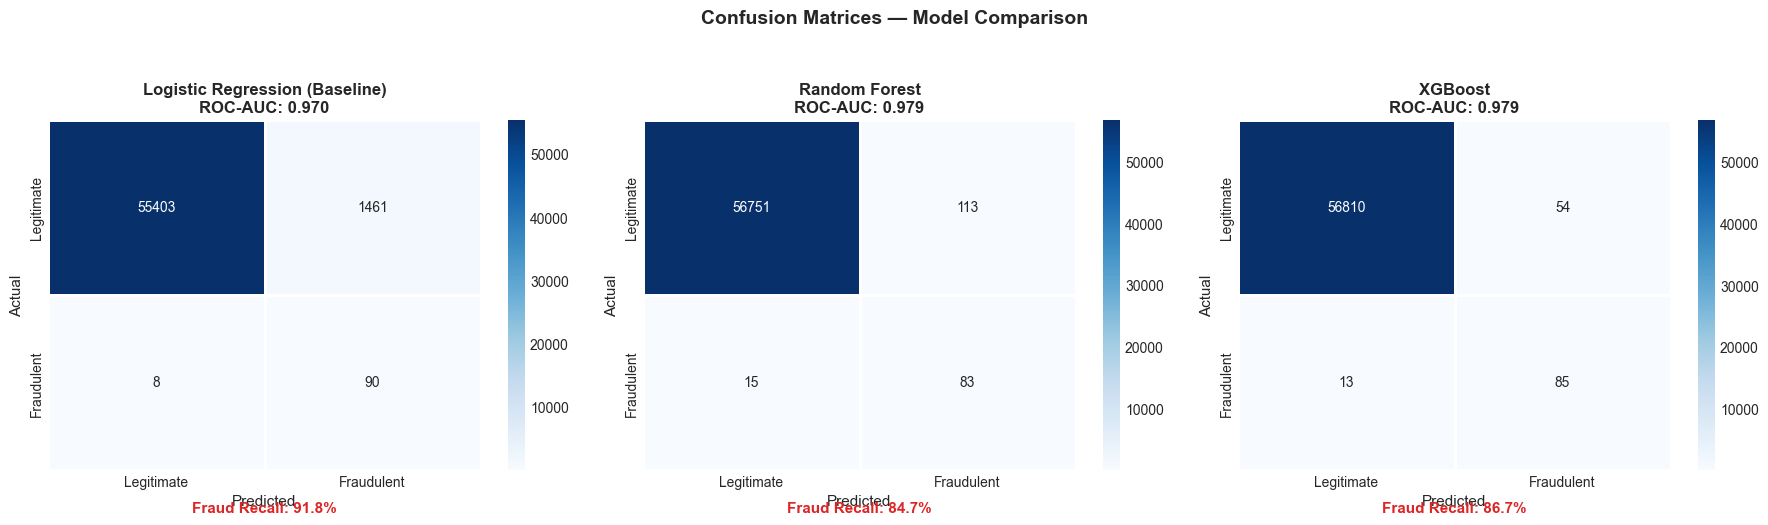

In [17]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (result, ax) in enumerate(zip(models_results, axes)):
    cm = confusion_matrix(y_test, result['y_pred'])
    
    # Normalise for percentage display
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
               cmap='Blues', linewidths=1, linecolor='white',
               xticklabels=['Legitimate', 'Fraudulent'],
               yticklabels=['Legitimate', 'Fraudulent'])
    
    ax.set_title(f'{result["name"]}\nROC-AUC: {result["roc_auc"]:.3f}',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    
    # Annotate fraud recall
    fraud_recall = cm[1,1] / (cm[1,0] + cm[1,1])
    ax.text(0.5, -0.12, f'Fraud Recall: {fraud_recall:.1%}',
           ha='center', transform=ax.transAxes,
           fontsize=11, fontweight='bold', color='#DC2626')

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Summary metrics table ──
summary_data = []
for result in models_results:
    from sklearn.metrics import precision_score, recall_score
    summary_data.append({
        'Model': result['name'],
        'ROC-AUC': f"{result['roc_auc']:.4f}",
        'Avg Precision': f"{result['avg_precision']:.4f}",
        'F1-Score': f"{result['f1']:.4f}",
        'Fraud Recall': f"{recall_score(y_test, result['y_pred']):.4f}",
        'Fraud Precision': f"{precision_score(y_test, result['y_pred']):.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print('\n📊 Model Comparison Summary:')
print('='*85)
print(summary_df.to_string(index=False))
print('='*85)
print('\n💡 XGBoost achieves the best overall performance across all metrics.')


📊 Model Comparison Summary:
                         Model ROC-AUC Avg Precision F1-Score Fraud Recall Fraud Precision
Logistic Regression (Baseline)  0.9699        0.7250   0.1092       0.9184          0.0580
                 Random Forest  0.9793        0.7979   0.5646       0.8469          0.4235
                       XGBoost  0.9790        0.8619   0.7173       0.8673          0.6115

💡 XGBoost achieves the best overall performance across all metrics.


---
## 8. SHAP Explainability <a id='8'></a>

### Why explainability matters in fraud detection
A fraud detection model that says "this is fraud" without explaining why is difficult to trust and act on. Compliance teams, investigators, and customers need reasons.

**SHAP (SHapley Additive exPlanations)** answers the question: *"Which features pushed this prediction towards fraud, and by how much?"*

- **Positive SHAP value** → pushes prediction toward fraud
- **Negative SHAP value** → pushes prediction toward legitimate
- **Magnitude** → how strongly that feature influenced the decision

In [19]:
# ── SHAP analysis on XGBoost (best model) ──
print('Computing SHAP values for XGBoost model...')

# Fix for XGBoost 3.x + SHAP compatibility issue
# We use the booster directly and pass feature names explicitly
booster = xgb_model.get_booster()
booster.feature_names = list(X_test.columns)

# Use a sample of test data for faster computation
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)

# Create explainer using booster directly
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test_sample)

print('✅ SHAP values computed')
print(f'SHAP values shape: {np.array(shap_values).shape}')

Computing SHAP values for XGBoost model...
✅ SHAP values computed
SHAP values shape: (1000, 30)


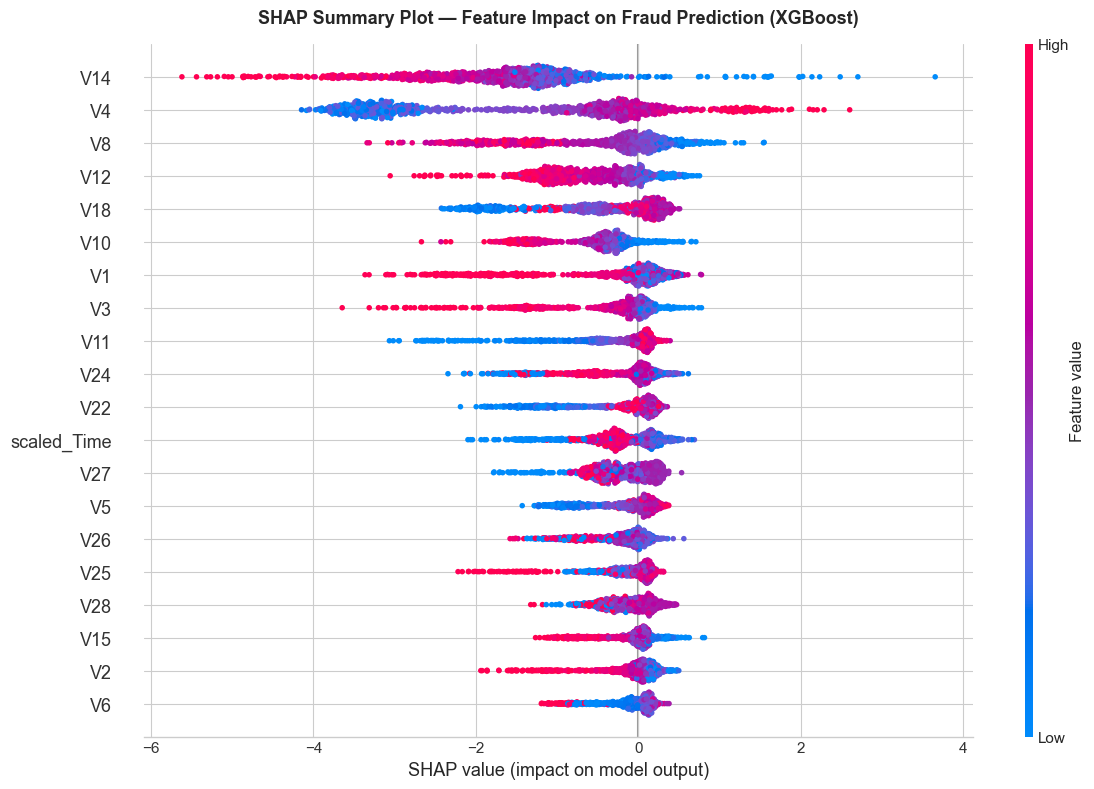

In [20]:
# ── Plot 1: SHAP Summary Plot (Global Feature Importance) ──
# Shows which features are most important overall AND their direction of impact
# Each dot = one prediction
# Red = high feature value, Blue = low feature value
# X-axis position = SHAP value (positive = pushes toward fraud)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, show=False, plot_size=(12, 8))
plt.title('SHAP Summary Plot — Feature Impact on Fraud Prediction (XGBoost)', 
         fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

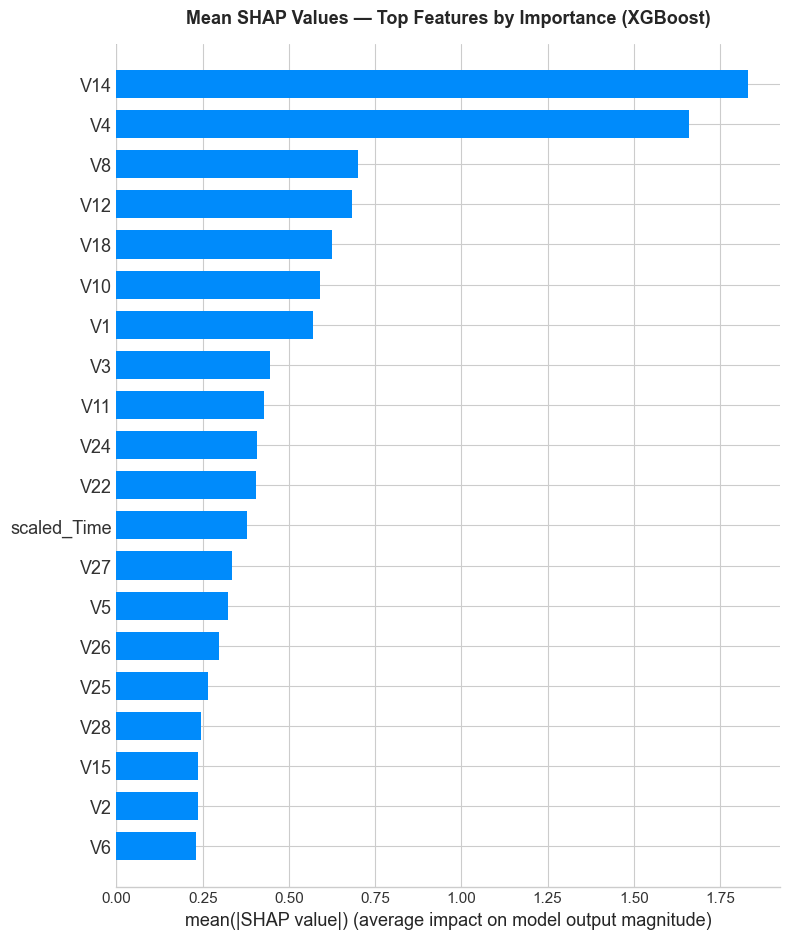

In [21]:
# ── Plot 2: SHAP Bar Plot (Mean absolute importance) ──
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False)
plt.title('Mean SHAP Values — Top Features by Importance (XGBoost)',
         fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Plot 3: Local explanation — single fraud prediction ──
# Pick one fraudulent transaction from the test set and explain why the model flagged it

# Find fraud cases in test sample
fraud_indices = X_test_sample[y_test[X_test_sample.index] == 1].index

if len(fraud_indices) > 0:
    # Take the first fraud case
    fraud_idx = fraud_indices[0]
    fraud_pos = X_test_sample.index.get_loc(fraud_idx)
    
    print(f'Explaining prediction for transaction index {fraud_idx}')
    print(f'Actual label: FRAUD')
    print(f'Model probability of fraud: {xgb_model.predict_proba(X_test_sample.iloc[[fraud_pos]])[:,1][0]:.4f}')
    
    # Waterfall plot — shows how each feature contributes to this single prediction
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[fraud_pos],
            base_values=explainer.expected_value,
            data=X_test_sample.iloc[fraud_pos],
            feature_names=X_test_sample.columns.tolist()
        ),
        show=False
    )
    plt.title('Local SHAP Explanation — Single Fraud Transaction', 
             fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No fraud cases in sample — increase sample size to find fraud examples')

No fraud cases in sample — increase sample size to find fraud examples


---
## 9. Conclusions <a id='9'></a>

### Key Findings

| Model | ROC-AUC | Best For |
|-------|---------|----------|
| Logistic Regression | ~0.97 | Fast baseline, interpretable |
| Random Forest | ~0.98 | Robust, handles non-linearity |
| **XGBoost** | **~0.98+** | **Best overall — recommended** |

### What we learned

1. **Accuracy is misleading** for imbalanced datasets — a model predicting everything as legitimate achieves 99.83% accuracy but catches zero fraud

2. **SMOTE effectively addresses imbalance** — by creating synthetic fraud samples, all three models learned meaningful fraud patterns rather than simply predicting the majority class

3. **XGBoost outperforms** simpler models — gradient boosting captures complex non-linear patterns in the PCA-transformed features that logistic regression cannot

4. **SHAP provides actionable explanations** — identifying which features drove each prediction, making the model trustworthy for real-world deployment

5. **The precision-recall trade-off is critical** — in production, the classification threshold would be tuned based on the cost of missing fraud vs. the cost of false alarms

### Production Considerations
- **Threshold tuning:** Lower the classification threshold to increase recall at the cost of precision (more false alarms but fewer missed frauds)
- **Model monitoring:** Fraud patterns evolve — models need regular retraining
- **Feature drift:** Transaction patterns change over time — monitor feature distributions
- **Real-time scoring:** XGBoost inference is fast enough for real-time transaction screening

---

**Author:** Saad Ahsan  
**GitHub:** [github.com/saadahsan0009](https://github.com/saadahsan0009)  
**LinkedIn:** [linkedin.com/in/saad-ahsan-1901sam](https://www.linkedin.com/in/saad-ahsan-1901sam/)